In [1]:
# Brain Tumor Classification Using Vision Transformers (ViT-b32)
# Framework: PyTorch | Environment: Visual Studio Code

# SECTION 1: Import Libraries
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
from transformers import ViTForImageClassification, AutoFeatureExtractor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd

c:\Users\JARE WORKS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:


# Set seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# SECTION 2: Set paths
train_path = 'C:/Users/JARE WORKS/Documents/aj project/ovie results/archive (3)/Training'
test_path = 'C:/Users/JARE WORKS/Documents/aj project/ovie results/archive (3)/Testing'

# Only these classes will be used
valid_classes = {'notumor', 'meningioma', 'glioma', 'pituitary'}

# Feature extractor
extractor = AutoFeatureExtractor.from_pretrained('google/vit-base-patch32-224-in21k')

# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=extractor.image_mean, std=extractor.image_std)
])

# Filter dataset by class
def filter_dataset(path, transform):
    base_dataset = datasets.ImageFolder(path, transform=transform)
    valid_indices = [
        i for i, (img_path, label) in enumerate(base_dataset.samples)
        if base_dataset.classes[label] in valid_classes
    ]
    filtered_dataset = Subset(base_dataset, valid_indices)
    return filtered_dataset

# Load and filter datasets
train_ds_full = filter_dataset(train_path, transform)
test_ds = filter_dataset(test_path, transform)

# Split training into train/val
val_size = int(0.2 * len(train_ds_full))
train_size = len(train_ds_full) - val_size
train_ds, val_ds = random_split(train_ds_full, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)
test_loader = DataLoader(test_ds, batch_size=16)

# SECTION 3: Define Model (ViT-b32)
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch32-224-in21k',
    num_labels=4
)
model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

# SECTION 4: Training Loop with AMP
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

def train(model, loader):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(images).logits
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)

# SECTION 5: Evaluation
def evaluate(model, loader, return_logits=False):
    model.eval()
    all_preds, all_labels, all_logits = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images).logits
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            if return_logits:
                all_logits.extend(outputs.cpu().numpy())
    if return_logits:
        return all_preds, all_labels, np.array(all_logits)
    return all_preds, all_labels

# SECTION 6: Training and Validation with Tracking
losses, f1s = [], []
for epoch in range(10):
    loss = train(model, train_loader)
    preds, labels = evaluate(model, val_loader)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Val Acc: {acc:.4f}, F1: {f1:.4f}")
    losses.append(loss)
    f1s.append(f1)

# Plot training loss and F1 score
plt.plot(range(1, 6), losses, label='Loss')
plt.plot(range(1, 6), f1s, label='F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('Training Progress')
plt.legend()
plt.show()

# SECTION 7: Test Evaluation
preds, labels, logits = evaluate(model, test_loader, return_logits=True)
print("\nTest Set Evaluation:")
print("Accuracy:", accuracy_score(labels, preds))
print("F1 Score:", f1_score(labels, preds, average='macro'))
print("ROC AUC (OVR):", roc_auc_score(labels, logits, multi_class='ovr'))
print("\nClassification Report:\n", classification_report(labels, preds, target_names=valid_classes, labels=[0, 1, 2, 3]))

# SECTION 8: Enhanced Confusion Matrix Plot
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
cm = confusion_matrix(labels, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=valid_classes, yticklabels=valid_classes)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# SECTION 9: Sample Prediction Visualization
def visualize_predictions(model, loader, class_names, num_images=5):
    model.eval()
    shown = 0
    plt.figure(figsize=(15, 5))
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images).logits
        preds = torch.argmax(outputs, dim=1)
        for i in range(len(images)):
            if shown >= num_images:
                break
            img = images[i].cpu().permute(1, 2, 0).numpy()
            img = (img * np.array(extractor.image_std) + np.array(extractor.image_mean)).clip(0, 1)
            plt.subplot(1, num_images, shown + 1)
            plt.imshow(img)
            plt.title(f"Pred: {class_names[preds[i]]}\nTrue: {class_names[labels[i]]}")
            plt.axis('off')
            shown += 1
        if shown >= num_images:
            break
    plt.show()

visualize_predictions(model, test_loader, class_names)

# SECTION 10: Save Model Checkpoint
checkpoint_dir = 'C:/Users/JARE WORKS/Documents/aj project/ovie results/directory'  # Change this to your desired path
os.makedirs(checkpoint_dir, exist_ok=True)
model_path = os.path.join(checkpoint_dir, "vit_brain_tumor_classifier.pth")
torch.save(model.state_dict(), model_path)
print(f"\n✅ Model saved to: {model_path}")

# SECTION 11: Export Metrics and Plot to Excel
# Create evaluation metrics DataFrame
metrics = {
    "Accuracy": [accuracy_score(labels, preds)],
    "F1 Score": [f1_score(labels, preds, average='macro')],
    "ROC AUC": [roc_auc_score(labels, logits, multi_class='ovr')]
}
metrics_df = pd.DataFrame(metrics)

# Get classification report as dict and convert to DataFrame
report_dict = classification_report(labels, preds, output_dict=True, target_names=class_names, labels=[0, 1, 2, 3])
report_df = pd.DataFrame(report_dict).transpose()

# Save confusion matrix plot
plot_path = 'ovie results/confusion_matrix.png'  # Change this to your desired path
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(plot_path)
print(f"✅ Confusion matrix saved at: {plot_path}")

# Save all metrics to Excel
excel_path = 'ovie results/metrics_report.xlsx'  # Change this to your desired path
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    metrics_df.to_excel(writer, index=False, sheet_name="Scores")
    report_df.to_excel(writer, sheet_name="Classification Report")
print(f"✅ Evaluation metrics saved at: {excel_path}")

# --- TEST SET PREDICTIONS (unlabeled) ---
print("\nRunning inference on test images (no ground truth labels)...")
predictions = []
model.eval()
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        output = model(images)
        predictions.append(output.item())

print("\nSample predictions (probabilities):")
for i, pred in enumerate(predictions[:10]):
    print(f"Image {i+1}: Probability of Leukemia = {pred:.4f}")

torch.save(model.state_dict(), "leukemia_cnn_all_main_model.pt")






Using device: cpu


C:\Users\JARE WORKS\AppData\Roaming\Python\Python312\site-packages\transformers\models\vit\feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'ovie results/archive (3)/Training'

In [ ]:
from sklearn.preprocessing import label_binarize

# Convert labels to one-hot if needed
labels_bin = label_binarize(labels, classes=[0, 1, 2, 3])  # adjust class list as needed

# Apply softmax to logits if not done already
logits_softmax = torch.softmax(torch.tensor(logits), dim=1).numpy()

print("ROC AUC (OVR):", roc_auc_score(labels_bin, logits_softmax, multi_class='ovr'))



c:\Users\JARE WORKS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


c:\Users\JARE WORKS\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\models\vit\feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch32-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\JARE WORKS\AppData\Local\Temp\ipykernel_12444\4284868168.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
c:\Users\JARE WORKS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\amp\grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not 

Epoch 1, Loss: 0.3748, Val Acc: 0.9720, F1: 0.9707


C:\Users\JARE WORKS\AppData\Local\Temp\ipykernel_12444\4284868168.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
c:\Users\JARE WORKS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


...

Epoch 3, Loss: 0.0453, Val Acc: 0.9553, F1: 0.9536


C:\Users\JARE WORKS\AppData\Local\Temp\ipykernel_12444\4284868168.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
c:\Users\JARE WORKS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Epoch 4, Loss: 0.0310, Val Acc: 0.9702, F1: 0.9692


C:\Users\JARE WORKS\AppData\Local\Temp\ipykernel_12444\4284868168.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
c:\Users\JARE WORKS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Epoch 5, Loss: 0.0397, Val Acc: 0.9834, F1: 0.9831


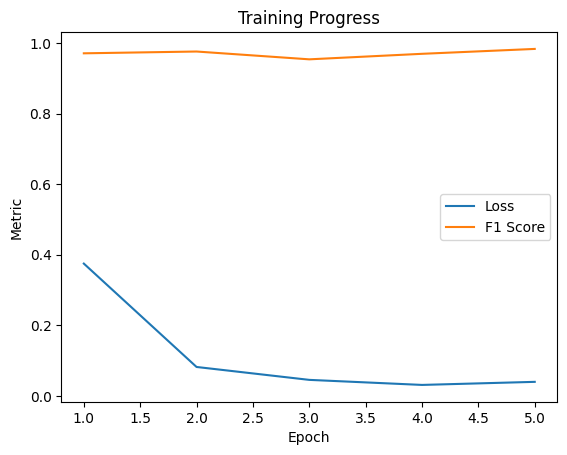


Test Set Evaluation:
Accuracy: 0.9877955758962624
F1 Score: 0.9870753305239273
ROC AUC (OVR): 0.9995690321785692

Classification Report:
               precision    recall  f1-score   support

      glioma       0.99      0.98      0.98       300
  meningioma       0.98      0.98      0.98       306
     notumor       0.99      1.00      1.00       405
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



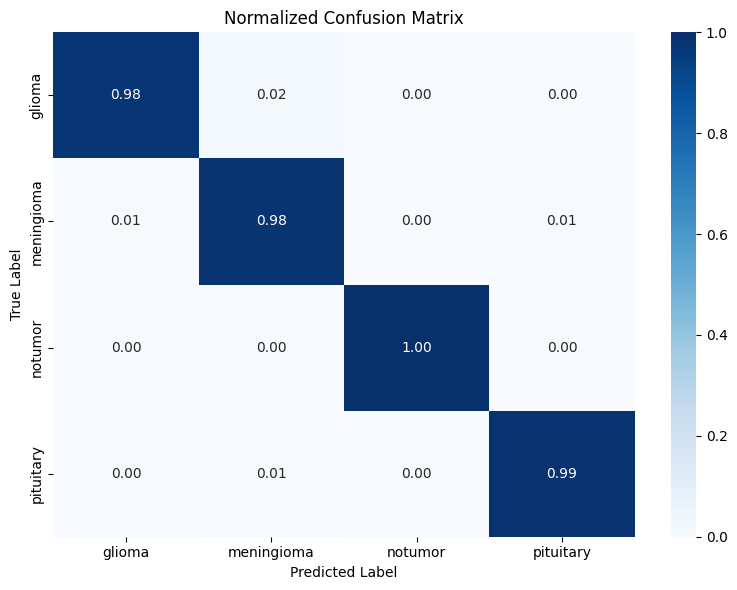

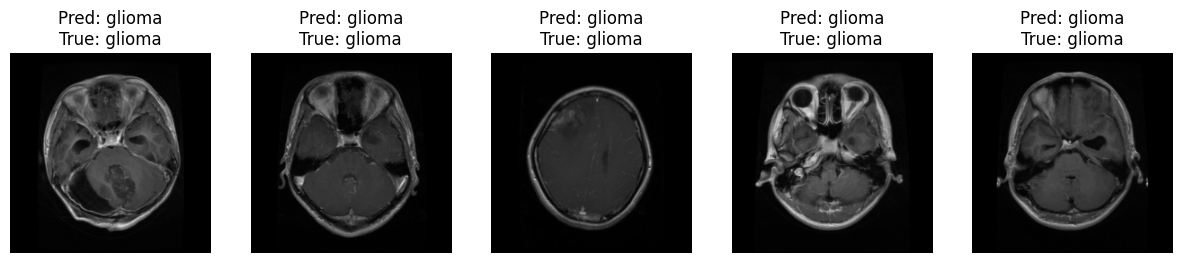


✅ Model saved to: C:/Users/JARE WORKS/Documents/aj project/ovie results/directory\vit_brain_tumor_classifier.pth
✅ Confusion matrix saved at: ovie results/confusion_matrix.png
✅ Evaluation metrics saved at: ovie results/metrics_report.xlsx


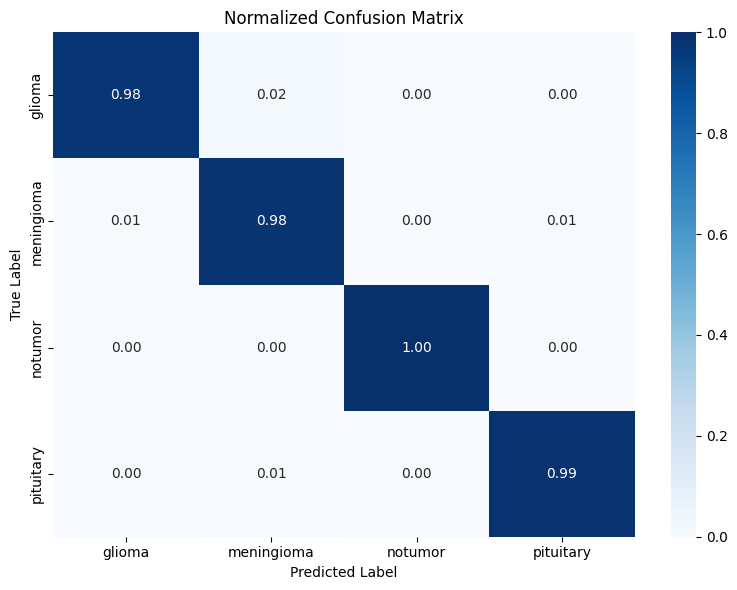

In [ ]:
vi

In [5]:
# SECTION 2: Set paths (Fixed using absolute or relative path handling)
base_dir = os.path.abspath("C:/Users/JARE WORKS/Documents/aj project/ovie results/archive (3)")
train_path = os.path.join(base_dir, "Training")
test_path = os.path.join(base_dir, "Testing")

# Sanity check
if not os.path.exists(train_path):
    raise FileNotFoundError(f"Training path not found: {train_path}")
if not os.path.exists(test_path):
    raise FileNotFoundError(f"Testing path not found: {test_path}")
